# Customer Segmentation using RFM Analysis

## Business Objective

Understanding customer behavior is important for improving customer retention and increasing business value.

The company has customer-level transaction data, but customers have different purchasing patterns. Some customers purchase frequently and contribute significant revenue, while others show declining engagement or become inactive over time.

This analysis uses RFM (Recency, Frequency, Monetary) analysis to segment customers based on their purchasing behavior.

The objective is to:

- Identify high-value customers
- Understand customer purchasing patterns
- Find customers with declining engagement
- Create meaningful customer segments
- Support targeted retention strategies

The output of this analysis will help the business make better customer-focused decisions.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: '%.2f' % x)

## 1.2 Load Customer 360 Dataset

The RFM analysis is performed on the Customer 360 dataset created during feature engineering.

Each row represents a unique customer with aggregated purchasing behavior.

In [3]:
# Load final Customer 360 clean dataset

customer_360 = pd.read_csv(
    r"D:\customer pulse AI project\1 data\03_analysis\customer_360_clean.csv"
)


customer_360.head()

,customer_unique_id,customer_city,customer_state,total_orders,delivered_orders,cancelled_orders,first_purchase_date,last_purchase_date,total_spent,average_order_value,maximum_order_value,minimum_order_value,average_payment_installments,preferred_payment_type,total_items_purchased,unique_products,unique_categories,favorite_category,average_items_per_order,average_review_score,average_delivery_days,average_delivery_delay,on_time_delivery_rate,delayed_delivery_rate,recency_days,customer_tenure_days,purchase_frequency,average_purchase_gap,spending_intensity,repeat_customer,cancel_rate,one_time_buyer,high_spender,vip_customer,loyal_customer,at_risk_customer,customer_value_tier,delivery_delay_category
0,861eff4711a542e4b93843c6dd7febb0,franca,SP,1,1,0,2017-05-16 15:05:35,2017-05-16 15:05:35,146.87,146.87,146.87,146.87,2.00,credit_card,1.00,1.00,1.00,moveis_escritorio,1.00,4.00,8.00,-11.00,1.00,0.00,520,0,1.00,0.00,146.87,0,0.00,1,1,0,0,1,Medium,Slightly Early
1,290c77bc529b7ac935b93aa66c333dc3,sao bernardo do campo,SP,1,1,0,2018-01-12 20:48:24,2018-01-12 20:48:24,335.48,335.48,335.48,335.48,8.00,credit_card,1.00,1.00,1.00,utilidades_domesticas,1.00,5.00,16.00,-8.00,1.00,0.00,278,0,1.00,0.00,335.48,0,0.00,1,1,0,0,1,High,On Time
2,060e732b5b29e8181a18229c7b0b2b5e,sao paulo,SP,1,1,0,2018-05-19 16:07:45,2018-05-19 16:07:45,157.73,157.73,157.73,157.73,7.00,credit_card,1.00,1.00,1.00,moveis_escritorio,1.00,5.00,26.00,1.00,0.00,1.00,152,0,1.00,0.00,157.73,0,0.00,1,1,0,0,0,High,Delayed
3,259dac757896d24d7702b9acbbff3f3c,mogi das cruzes,SP,1,1,0,2018-03-13 16:06:38,2018-03-13 16:06:38,173.30,173.30,173.30,173.30,1.00,credit_card,1.00,1.00,1.00,moveis_escritorio,1.00,5.00,14.00,-13.00,1.00,0.00,219,0,1.00,0.00,173.30,0,0.00,1,1,0,0,1,High,Slightly Early
4,345ecd01c38d18a9036ed96c73b8d066,campinas,SP,1,1,0,2018-07-29 09:51:30,2018-07-29 09:51:30,252.25,252.25,252.25,252.25,8.00,credit_card,1.00,1.00,1.00,casa_conforto,1.00,5.00,11.00,-6.00,1.00,0.00,81,0,1.00,0.00,252.25,0,0.00,1,1,0,0,0,High,On Time


In [4]:
# Checking dataset dimensions

print("Customer 360 Dataset Shape:", customer_360.shape)

Customer 360 Dataset Shape: (96096, 38)


In [5]:
# Checking dataset structure

customer_360.info()

<class 'pandas.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_unique_id            96096 non-null  str    
 1   customer_city                 96096 non-null  str    
 2   customer_state                96096 non-null  str    
 3   total_orders                  96096 non-null  int64  
 4   delivered_orders              96096 non-null  int64  
 5   cancelled_orders              96096 non-null  int64  
 6   first_purchase_date           96096 non-null  str    
 7   last_purchase_date            96096 non-null  str    
 8   total_spent                   96096 non-null  float64
 9   average_order_value           96096 non-null  float64
 10  maximum_order_value           96096 non-null  float64
 11  minimum_order_value           96096 non-null  float64
 12  average_payment_installments  96096 non-null  float64
 13  preferred_pa

In [6]:
# Convert date columns into datetime format

date_columns = [
    "first_purchase_date",
    "last_purchase_date"
]

for col in date_columns:
    customer_360[col] = pd.to_datetime(customer_360[col])


customer_360[date_columns].dtypes

first_purchase_date    datetime64[us]
last_purchase_date     datetime64[us]
dtype: object

In [7]:
customer_360.info()

<class 'pandas.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   customer_unique_id            96096 non-null  str           
 1   customer_city                 96096 non-null  str           
 2   customer_state                96096 non-null  str           
 3   total_orders                  96096 non-null  int64         
 4   delivered_orders              96096 non-null  int64         
 5   cancelled_orders              96096 non-null  int64         
 6   first_purchase_date           96096 non-null  datetime64[us]
 7   last_purchase_date            96096 non-null  datetime64[us]
 8   total_spent                   96096 non-null  float64       
 9   average_order_value           96096 non-null  float64       
 10  maximum_order_value           96096 non-null  float64       
 11  minimum_order_value           96096 non

In [8]:
customer_360.columns.tolist()

['customer_unique_id',
 'customer_city',
 'customer_state',
 'total_orders',
 'delivered_orders',
 'cancelled_orders',
 'first_purchase_date',
 'last_purchase_date',
 'total_spent',
 'average_order_value',
 'maximum_order_value',
 'minimum_order_value',
 'average_payment_installments',
 'preferred_payment_type',
 'total_items_purchased',
 'unique_products',
 'unique_categories',
 'favorite_category',
 'average_items_per_order',
 'average_review_score',
 'average_delivery_days',
 'average_delivery_delay',
 'on_time_delivery_rate',
 'delayed_delivery_rate',
 'recency_days',
 'customer_tenure_days',
 'purchase_frequency',
 'average_purchase_gap',
 'spending_intensity',
 'repeat_customer',
 'cancel_rate',
 'one_time_buyer',
 'high_spender',
 'vip_customer',
 'loyal_customer',
 'at_risk_customer',
 'customer_value_tier',
 'delivery_delay_category']

In [9]:
customer_360.dtypes

customer_unique_id                         str
customer_city                              str
customer_state                             str
total_orders                             int64
delivered_orders                         int64
cancelled_orders                         int64
first_purchase_date             datetime64[us]
last_purchase_date              datetime64[us]
total_spent                            float64
average_order_value                    float64
maximum_order_value                    float64
minimum_order_value                    float64
average_payment_installments           float64
preferred_payment_type                     str
total_items_purchased                  float64
unique_products                        float64
unique_categories                      float64
favorite_category                          str
average_items_per_order                float64
average_review_score                   float64
average_delivery_days                  float64
average_deliv

## 1.5 Standardize RFM Column Names

The selected columns are renamed according to standard RFM terminology to improve readability and analysis.

In [11]:
# Selecting required features for RFM analysis

rfm = customer_360[
    [
        "customer_unique_id",
        "recency_days",
        "total_orders",
        "total_spent"
    ]
].copy()


rfm.head()

,customer_unique_id,recency_days,total_orders,total_spent
0,861eff4711a542e4b93843c6dd7febb0,520,1,146.87
1,290c77bc529b7ac935b93aa66c333dc3,278,1,335.48
2,060e732b5b29e8181a18229c7b0b2b5e,152,1,157.73
3,259dac757896d24d7702b9acbbff3f3c,219,1,173.30
4,345ecd01c38d18a9036ed96c73b8d066,81,1,252.25


In [12]:
# Rename columns according to RFM terminology

rfm.rename(
    columns={
        "customer_unique_id": "customer_id",
        "recency_days": "recency",
        "total_orders": "frequency",
        "total_spent": "monetary"
    },
    inplace=True
)


rfm.head()

,customer_id,recency,frequency,monetary
0,861eff4711a542e4b93843c6dd7febb0,520,1,146.87
1,290c77bc529b7ac935b93aa66c333dc3,278,1,335.48
2,060e732b5b29e8181a18229c7b0b2b5e,152,1,157.73
3,259dac757896d24d7702b9acbbff3f3c,219,1,173.30
4,345ecd01c38d18a9036ed96c73b8d066,81,1,252.25


In [13]:
#validation
rfm.shape

(96096, 4)

In [15]:
rfm.columns

Index(['customer_id', 'recency', 'frequency', 'monetary'], dtype='str')

In [16]:
rfm.dtypes

customer_id        str
recency          int64
frequency        int64
monetary       float64
dtype: object

In [17]:
rfm.isnull().sum()

customer_id    0
recency        0
frequency      0
monetary       0
dtype: int64

In [18]:
rfm.duplicated().sum()

np.int64(0)

In [19]:
rfm.describe()

,recency,frequency,monetary
count,96096.00,96096.00,96096.00
mean,288.74,1.03,166.59
std,153.41,0.21,231.43
min,1.00,1.00,0.00
25%,164.00,1.00,63.12
50%,269.00,1.00,108.00
75%,398.00,1.00,183.53
max,773.00,17.00,13664.08


## RFM Dataset Summary

The RFM dataset contains customer-level purchase behavior information for 96,096 customers.

The dataset includes three key metrics:

- Recency: Number of days since the customer's last purchase
- Frequency: Total number of orders placed by the customer
- Monetary: Total amount spent by the customer

The statistical summary helps understand customer purchase patterns before applying RFM scoring and segmentation.

## Business Observations

### Recency

- The average recency value is approximately 289 days.
- Customers have a wide range of purchase activity, with some customers purchasing recently while others have not purchased for more than a year.

### Frequency

- The average order frequency is 1.03 orders per customer.
- The median frequency is 1 order, indicating that most customers have made only a single purchase.

### Monetary

- The average customer spending is approximately 166.59.
- Customer spending varies significantly, with some customers contributing much higher revenue compared to others.

These observations show differences in customer engagement and value, which makes customer segmentation necessary.

# Part 2: RFM Metric Analysis
# 2.1 Recency Analysis

Recency measures the number of days since the customer's last purchase.

A lower recency value indicates that the customer has purchased recently, while a higher value indicates reduced customer activity.

This analysis helps understand the current activity level of customers before assigning RFM scores.

In [20]:
# Recency statistics

rfm["recency"].describe()

count   96096.00
mean      288.74
std       153.41
min         1.00
25%       164.00
50%       269.00
75%       398.00
max       773.00
Name: recency, dtype: float64

## Recency Summary

The recency metric shows the number of days since the customer's last purchase.

The dataset contains recency values for 96,096 customers.

Key observations:

- The average recency is approximately 289 days.
- The minimum recency is 1 day, indicating recently active customers.
- The maximum recency is 773 days, showing customers with very low recent activity.
- The median recency is 269 days, meaning half of the customers have not purchased for more than 269 days.

The wide range of recency values indicates different levels of customer activity, which will help in creating customer segments.

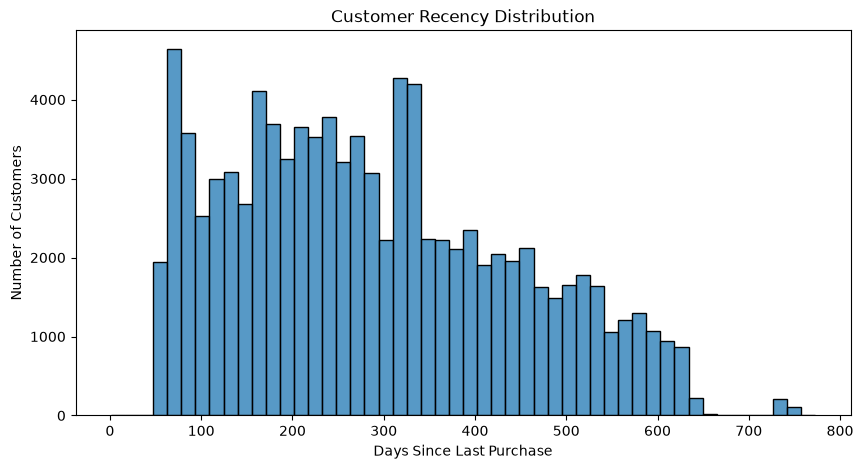

In [22]:
#2.1.2 Recency Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    data=rfm,
    x="recency",
    bins=50
)

plt.title("Customer Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.show()

## Recency Distribution Observation

The recency distribution shows the variation in customer activity based on the number of days since the last purchase.

Key observations:

- Customer recency values range from 1 day to 773 days.
- A large number of customers have higher recency values, indicating that many customers have not purchased recently.
- The distribution shows a gradual increase in inactive customers as the number of days since last purchase increases.
- Recently active customers represent a smaller portion of the customer base compared to customers with longer purchase gaps.

This indicates that customer activity is not uniform, and different groups of customers require different engagement strategies.

In [24]:
# Creating customer recency groups

def recency_group(days):
    if days <= 90:
        return "Active Customers"
    elif days <= 180:
        return "Recent Customers"
    elif days <= 365:
        return "Inactive Customers"
    else:
        return "Highly Inactive Customers"


rfm["recency_group"] = rfm["recency"].apply(recency_group)


rfm["recency_group"].value_counts()

recency_group
Inactive Customers           39801
Highly Inactive Customers    28551
Recent Customers             18332
Active Customers              9412
Name: count, dtype: int64

In [25]:
# Customer percentage by recency group

recency_summary = (
    rfm["recency_group"]
    .value_counts()
    .reset_index()
)

recency_summary.columns = [
    "recency_group",
    "customer_count"
]


recency_summary["percentage"] = (
    recency_summary["customer_count"] /
    len(rfm) * 100
)


recency_summary

,recency_group,customer_count,percentage
0,Inactive Customers,39801,41.42
1,Highly Inactive Customers,28551,29.71
2,Recent Customers,18332,19.08
3,Active Customers,9412,9.79


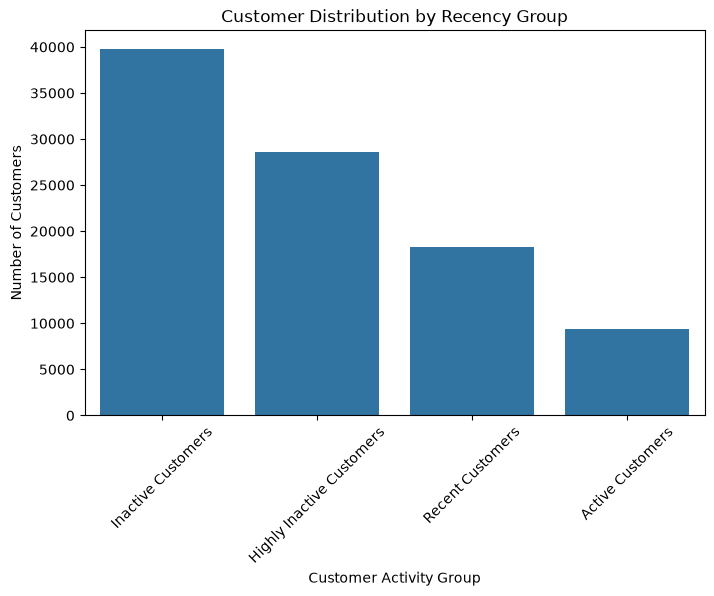

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=recency_summary,
    x="recency_group",
    y="customer_count"
)

plt.title("Customer Distribution by Recency Group")
plt.xlabel("Customer Activity Group")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

## Recency Group Insights

The customer base shows different levels of purchase activity.

Key observations:

- A large proportion of customers fall under inactive and highly inactive categories, indicating reduced recent purchasing activity.
- Active customers represent a smaller group compared to customers with longer purchase gaps.
- The distribution highlights the need to identify customers with declining engagement and understand their behavior further.

These customer groups will be combined with frequency and monetary values during RFM segmentation.

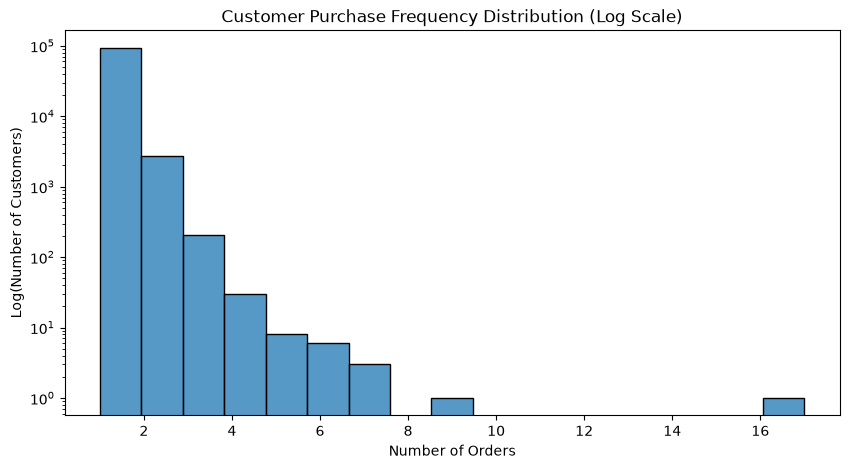

In [43]:
#frequency distribution
plt.figure(figsize=(10,5))

sns.histplot(
    rfm["frequency"],
    bins=17
)

plt.yscale("log")

plt.title("Customer Purchase Frequency Distribution (Log Scale)")
plt.xlabel("Number of Orders")
plt.ylabel("Log(Number of Customers)")

plt.show()

In [32]:
frequency_summary = (
    rfm["frequency"]
    .value_counts()
    .sort_index()
    .reset_index()
)

frequency_summary.columns = ["Number_of_Orders", "Customer_Count"]

frequency_summary["Percentage"] = (
    frequency_summary["Customer_Count"] /
    len(rfm) * 100
).round(2)

frequency_summary

,Number_of_Orders,Customer_Count,Percentage
0,1,93099,96.88
1,2,2745,2.86
2,3,203,0.21
3,4,30,0.03
4,5,8,0.01
5,6,6,0.01
6,7,3,0.00
7,9,1,0.00
8,17,1,0.00


## Frequency Analysis Insights

The purchase frequency distribution reveals a strong imbalance in customer purchasing behavior.

### Key Findings

- Approximately 96.88% of customers have placed only one order.
- Only 2.86% of customers returned for a second purchase.
- Customers with three or more purchases represent less than 0.3% of the customer base.
- Highly loyal customers are extremely rare, with only a few customers placing more than five orders.

### Business Interpretation

The results indicate that customer acquisition is significantly stronger than customer retention.

The business experiences a substantial decline in repeat purchasing after the first order, suggesting opportunities to improve customer engagement and loyalty.

Increasing the conversion of one-time buyers into repeat customers can significantly improve customer lifetime value (CLV) and reduce customer churn.

## 2.4 Monetary Analysis

### Objective

Monetary analysis evaluates the financial value of customers by measuring the total amount spent on purchases.

This analysis helps identify:

- High-value customers
- Low-value customers
- Revenue contribution patterns
- Spending distribution across the customer base

The insights from monetary analysis will be used to assign Monetary (M) scores during RFM scoring.

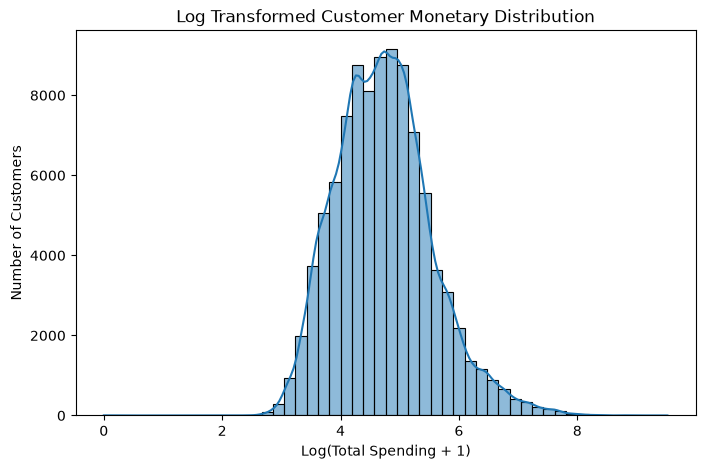

In [36]:
#monetary distribution
plt.figure(figsize=(8,5))

sns.histplot(
    np.log1p(rfm["monetary"]),
    bins=50,
    kde=True
)

plt.title("Log Transformed Customer Monetary Distribution")
plt.xlabel("Log(Total Spending + 1)")
plt.ylabel("Number of Customers")

plt.show()

In [37]:
rfm["monetary"].describe().round(2)

count   96096.00
mean      166.59
std       231.43
min         0.00
25%        63.12
50%       108.00
75%       183.53
max     13664.08
Name: monetary, dtype: float64

In [38]:
#spending distribution table
rfm["monetary"].describe(percentiles=[0.25,0.5,0.75,0.90,0.95,0.99]).round(2)

count   96096.00
mean      166.59
std       231.43
min         0.00
25%        63.12
50%       108.00
75%       183.53
90%       319.57
95%       476.15
99%      1122.46
max     13664.08
Name: monetary, dtype: float64

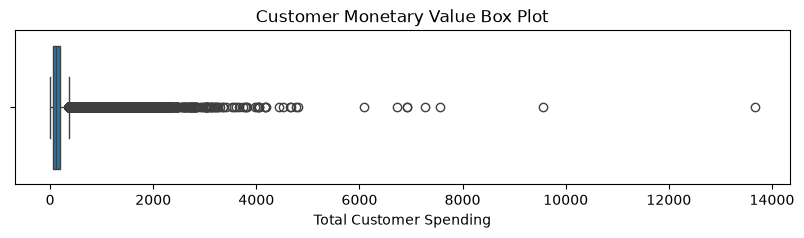

In [40]:
plt.figure(figsize=(10,2))

sns.boxplot(x=rfm["monetary"])

plt.title("Customer Monetary Value Box Plot")
plt.xlabel("Total Customer Spending")

plt.show()

In [41]:
#percentile analysiis
rfm["monetary"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

count   96096.00
mean      166.59
std       231.43
min         0.00
25%        63.12
50%       108.00
75%       183.53
90%       319.57
95%       476.15
99%      1122.46
max     13664.08
Name: monetary, dtype: float64

## Monetary Analysis Insights

Monetary analysis evaluates the financial contribution of customers to the business.

### Key Findings

- The median customer spending is 108.00, while the average spending is 166.59, indicating a right-skewed spending distribution.
- Approximately 75% of customers spend less than 183.53, showing that most customers contribute relatively low revenue.
- The top 10%, 5%, and 1% of customers contribute substantially higher spending, representing valuable customer segments.
- A small number of customers exhibit exceptionally high spending, with the maximum spending reaching 13,664.08.

### Business Interpretation

Customer revenue is concentrated among a relatively small group of high-value customers. Protecting these customers through personalized engagement, loyalty programs, and premium services can significantly improve customer lifetime value (CLV).

The presence of a highly skewed spending distribution supports the use of quantile-based scoring for the Monetary component during RFM analysis.

# Part 3: RFM Scoring Methodology

## Objective

The objective of this section is to convert the three RFM metrics into standardized scores.

Since Recency, Frequency, and Monetary have different scales, they cannot be compared directly.

Therefore, each metric will be converted into a score ranging from 1 to 5 using quantile-based ranking.

These scores will then be combined to create the final RFM score for each customer.

## Why Quantile-Based Scoring?

The three RFM metrics have different numerical ranges:

- Recency is measured in days.
- Frequency is measured as the number of orders.
- Monetary is measured as total customer spending.

Direct comparison is not meaningful because the scales differ significantly.

Quantile-based scoring divides customers into groups of similar size, allowing fair comparison across all three metrics.

Scoring Scale:

| Score | Interpretation |
|------|----------------|
| 5 | Best |
| 4 | Good |
| 3 | Average |
| 2 | Below Average |
| 1 | Poor |

In [44]:
#3.2 Recency Score Calculation
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    q=5,
    labels=[5,4,3,2,1]
).astype(int)

In [46]:
#validate
rfm["R_score"].value_counts().sort_index()

R_score
1    19130
2    19300
3    19043
4    19299
5    19324
Name: count, dtype: int64

## 3.3 Frequency Score Calculation
Why Business Rule Instead of Quantile?

The Frequency variable contains only a few unique values and nearly 97% of customers have placed only one order.

Using quantile-based scoring would assign different scores to customers with the same purchase frequency.

Therefore, a business rule-based scoring approach is used for the Frequency metric.

In [47]:
def frequency_score(x):

    if x == 1:
        return 1
    elif x == 2:
        return 2
    elif x == 3:
        return 3
    elif x <= 5:
        return 4
    else:
        return 5


rfm["F_score"] = rfm["frequency"].apply(frequency_score)

In [48]:
rfm["F_score"].value_counts().sort_index()

F_score
1    93099
2     2745
3      203
4       38
5       11
Name: count, dtype: int64

In [49]:
#3.4 Monetary Score Calculation
rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    q=5,
    labels=[1,2,3,4,5]
).astype(int)

In [50]:
rfm["M_score"].value_counts().sort_index()

M_score
1    19222
2    19219
3    19222
4    19214
5    19219
Name: count, dtype: int64

In [53]:
#3.6 Validate Scores ,Score Distribution
print("Recency Score Distribution")
print(rfm["R_score"].value_counts().sort_index())

print("\nFrequency Score Distribution")
print(rfm["F_score"].value_counts().sort_index())

print("\nMonetary Score Distribution")
print(rfm["M_score"].value_counts().sort_index())

Recency Score Distribution
R_score
1    19130
2    19300
3    19043
4    19299
5    19324
Name: count, dtype: int64

Frequency Score Distribution
F_score
1    93099
2     2745
3      203
4       38
5       11
Name: count, dtype: int64

Monetary Score Distribution
M_score
1    19222
2    19219
3    19222
4    19214
5    19219
Name: count, dtype: int64


## RFM Score Distribution Analysis

The distribution of RFM scores was validated after applying the scoring methodology.

### Recency Score

The Recency score is evenly distributed across all five score levels because quantile-based scoring was applied. Customers with more recent purchases received higher scores, while customers with longer inactivity periods received lower scores.

### Frequency Score

The Frequency score is highly concentrated in Score 1 because approximately 96.88% of customers placed only one order. This reflects the actual purchase behavior of the dataset and highlights low customer retention.

### Monetary Score

The Monetary score is evenly distributed using quantile-based scoring. Customers with higher total spending received higher Monetary scores, enabling effective identification of high-value customers.

Overall, the standardized RFM scores provide a reliable foundation for customer segmentation and subsequent business analysis.

In [54]:
# Create RFM Score

rfm["RFM_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

In [55]:
# Total RFM Score

rfm["RFM_total_score"] = (
    rfm["R_score"] +
    rfm["F_score"] +
    rfm["M_score"]
)

In [56]:
rfm.head()

,customer_id,recency,frequency,monetary,recency_group,R_score,F_score,M_score,RFM_score,RFM_total_score
0,861eff4711a542e4b93843c6dd7febb0,520,1,146.87,Highly Inactive Customers,1,1,4,114,6
1,290c77bc529b7ac935b93aa66c333dc3,278,1,335.48,Inactive Customers,3,1,5,315,9
2,060e732b5b29e8181a18229c7b0b2b5e,152,1,157.73,Recent Customers,4,1,4,414,9
3,259dac757896d24d7702b9acbbff3f3c,219,1,173.30,Inactive Customers,4,1,4,414,9
4,345ecd01c38d18a9036ed96c73b8d066,81,1,252.25,Active Customers,5,1,5,515,11


In [57]:
#Validate RFM Scores
rfm[[
    "R_score",
    "F_score",
    "M_score",
    "RFM_total_score"
]].describe()

,R_score,F_score,M_score,RFM_total_score
count,96096.00,96096.00,96096.00,96096.00
mean,3.00,1.03,3.00,7.04
std,1.42,0.20,1.41,2.05
min,1.00,1.00,1.00,3.00
25%,2.00,1.00,2.00,6.00
50%,3.00,1.00,3.00,7.00
75%,4.00,1.00,4.00,9.00
max,5.00,5.00,5.00,15.00


## RFM Score Validation

The generated RFM scores were validated to ensure consistency and correctness.

### Key Observations

- Recency scores are evenly distributed because quantile-based scoring divides customers into approximately equal groups.
- Frequency scores are highly concentrated in Score 1, reflecting that most customers placed only one order.
- Monetary scores are evenly distributed using quantile-based scoring.
- The average RFM Total Score is 7.04 (out of 15), indicating that the customer base consists primarily of low-engagement customers with limited repeat purchasing behavior.

### Business Interpretation

The validation confirms that the scoring methodology accurately represents customer purchasing behavior and provides a reliable foundation for customer segmentation.

# 4. Customer Segmentation using RFM Analysis

## Objective

After calculating RFM scores, the next step is to group customers with similar purchasing behavior. Customer segmentation helps identify valuable customers, understand buying patterns, and support better marketing and retention decisions.

In this project, a custom RFM segmentation approach is used because the dataset contains a very high percentage of one-time buyers.

## Why Custom Segmentation?

Standard RFM segmentation works well when customers purchase multiple times. However, the Olist dataset shows a different pattern.

Frequency analysis revealed that most customers placed only one order, making the frequency distribution highly skewed. Because of this, standard RFM segments such as Champions or Loyal Customers would not represent the actual customer behavior.

Instead of using predefined rules, customer segments are created based on the distribution of this dataset and business understanding.

In [61]:
# Frequency distribution of customers

frequency_distribution = (
    rfm["frequency"]
    .value_counts()
    .sort_index()
    .reset_index()
)

frequency_distribution.columns = [
    "Number of Orders",
    "Customers"
]

frequency_distribution["Percentage"] = (
    frequency_distribution["Customers"]
    / len(rfm)
    * 100
).round(2)

frequency_distribution

,Number of Orders,Customers,Percentage
0,1,93099,96.88
1,2,2745,2.86
2,3,203,0.21
3,4,30,0.03
4,5,8,0.01
5,6,6,0.01
6,7,3,0.00
7,9,1,0.00
8,17,1,0.00


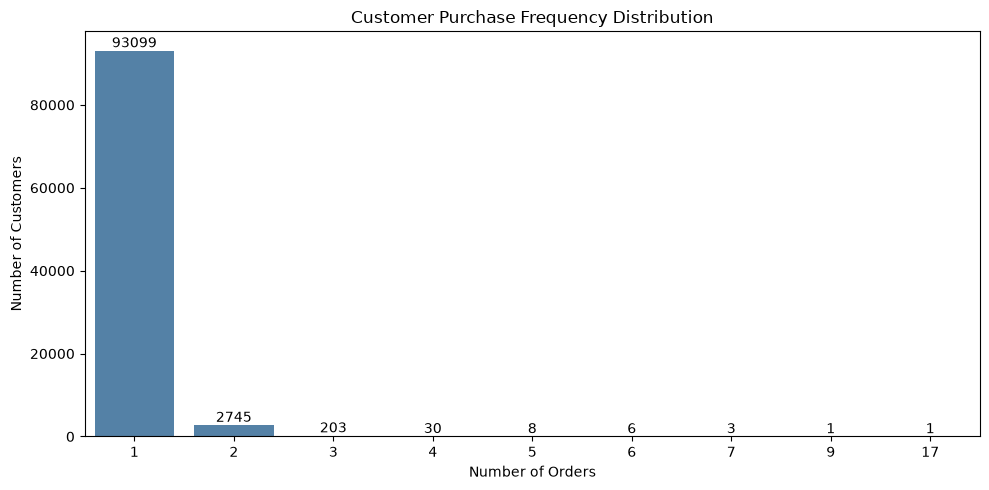

In [63]:
#visualization
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=frequency_distribution,
    x="Number of Orders",
    y="Customers",
    color="steelblue"
)

plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Key Observations

- Out of **96,096** customers, **93,099** placed only one order.
- Around **96.88%** of customers are one-time buyers.
- Only **3.12%** of customers made more than one purchase.
- The number of repeat customers decreases rapidly as purchase frequency increases.
- This indicates that the purchase frequency is highly right-skewed.

### Business Insight

The frequency analysis shows that customer retention is relatively low, with most customers making only a single purchase.

Because repeat purchases are rare, Frequency alone cannot effectively distinguish customer value. A more meaningful segmentation can be achieved by combining Recency and Monetary with Frequency.

For this reason, a custom RFM segmentation strategy will be developed in the next section.

## 4.2 Customer Segmentation Strategy

The frequency analysis showed that most customers placed only one order. Therefore, traditional RFM segments are not suitable for this dataset.

A custom segmentation strategy is used by combining **Recency**, **Frequency**, and **Monetary** scores. The objective is to group customers with similar purchasing behavior and identify customers requiring different marketing and retention strategies.

### Segmentation Rules

Customers are divided into six business segments based on their RFM scores.

| Segment | Business Meaning |
|----------|------------------|
| Premium Customers | Recent, high spending, and repeat customers |
| High Value Customers | Recent customers with high purchase value |
| Active Customers | Recently active customers with good engagement |
| Promising Customers | Customers with moderate value and growth potential |
| Price Sensitive Customers | Recent customers with lower spending |
| Lost Customers | Inactive customers with low engagement |

In [64]:
#create customer segmentation
def customer_segment(row):

    if row["R_score"] >= 4 and row["F_score"] >= 3 and row["M_score"] >= 4:
        return "Premium Customers"

    elif row["R_score"] >= 4 and row["M_score"] >= 4:
        return "High Value Customers"

    elif row["RFM_total_score"] >= 8:
        return "Active Customers"

    elif row["RFM_total_score"] >= 6:
        return "Promising Customers"

    elif row["R_score"] >= 3 and row["M_score"] <= 2:
        return "Price Sensitive Customers"

    else:
        return "Lost Customers"


rfm["customer_segment"] = rfm.apply(customer_segment, axis=1)

In [65]:
#Segment Distribution
segment_distribution = (
    rfm["customer_segment"]
    .value_counts()
    .reset_index()
)

segment_distribution.columns = [
    "Customer Segment",
    "Customers"
]

segment_distribution["Percentage"] = (
    segment_distribution["Customers"]
    / len(rfm) * 100
).round(2)

segment_distribution

,Customer Segment,Customers,Percentage
0,Promising Customers,33210,34.56
1,Active Customers,23467,24.42
2,Lost Customers,19559,20.35
3,High Value Customers,15774,16.41
4,Price Sensitive Customers,3949,4.11
5,Premium Customers,137,0.14


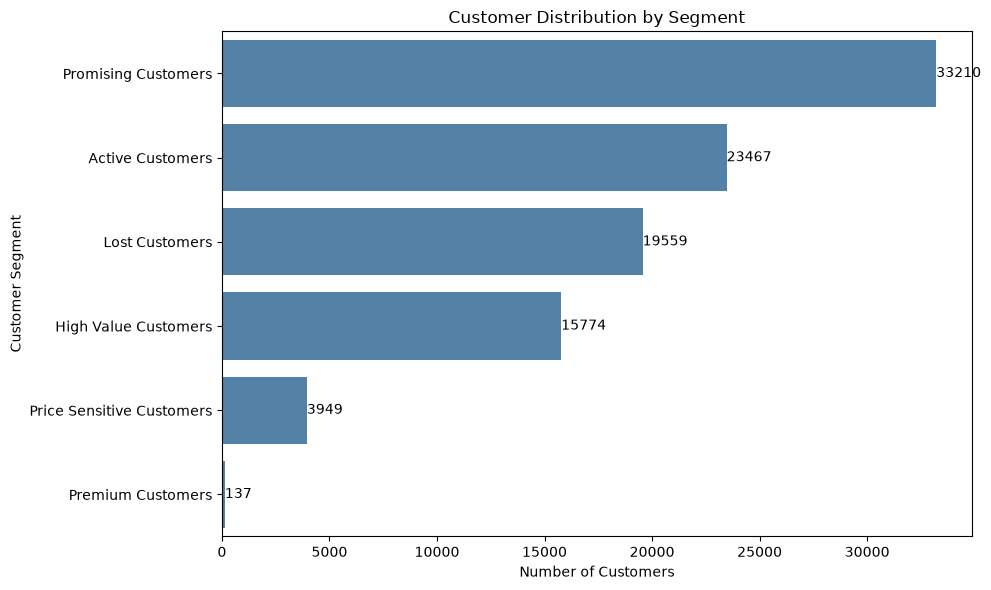

In [66]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=segment_distribution,
    x="Customers",
    y="Customer Segment",
    color="steelblue"
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Key Findings

- Promising Customers represent the largest customer group (34.56%).
- Active Customers account for nearly one-fourth of the customer base (24.42%).
- Around 20% of customers fall into the Lost Customer segment, highlighting a potential retention opportunity.
- High Value Customers contribute a significant portion of the customer base (16.41%) and should be prioritized for loyalty programs.
- Premium Customers represent only 0.14% of customers, making them an exclusive and valuable segment.

### Business Insight

The segmentation reveals that most customers are either in the **Promising** or **Active** category, suggesting strong potential for future growth if they are engaged effectively.

Although Premium Customers represent a very small percentage of the customer base, they are expected to contribute disproportionately to revenue and should receive personalized retention strategies.

The Lost Customer segment is also substantial, indicating an opportunity for targeted win-back campaigns to improve customer retention.

## 4.3 Segment Performance Analysis

After creating the customer segments, the next step is to compare their overall performance.

Each segment is evaluated using key business metrics such as customer count, average recency, purchase frequency, spending, and revenue contribution. This helps identify the most valuable customer groups and supports business decisions for marketing and retention.

In [69]:
#create segment summary
segment_summary = (
    rfm.groupby("customer_segment")
    .agg(
        Customers=("customer_id", "count"),
        Avg_Recency=("recency", "mean"),
        Avg_Frequency=("frequency", "mean"),
        Avg_Monetary=("monetary", "mean"),
        Total_Revenue=("monetary", "sum"),
        Avg_RFM_Score=("RFM_total_score", "mean")
    )
)

segment_summary["Customer_%"] = (
    segment_summary["Customers"] /
    segment_summary["Customers"].sum() * 100
)

segment_summary["Revenue_%"] = (
    segment_summary["Total_Revenue"] /
    segment_summary["Total_Revenue"].sum() * 100
)

segment_summary = (
    segment_summary[
        [
            "Customers",
            "Customer_%",
            "Avg_Recency",
            "Avg_Frequency",
            "Avg_Monetary",
            "Total_Revenue",
            "Revenue_%",
            "Avg_RFM_Score"
        ]
    ]
    .sort_values("Total_Revenue", ascending=False)
    .round(2)
)

segment_summary

,Customers,Customer_%,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_%,Avg_RFM_Score
customer_segment,,,,,,,,
Active Customers,23467,24.42,218.81,1.07,221.61,5200544.23,32.49,8.37
High Value Customers,15774,16.41,141.79,1.06,307.37,4848409.30,30.29,10.05
Promising Customers,33210,34.56,308.75,1.01,133.35,4428567.47,27.66,6.56
Lost Customers,19559,20.35,462.07,1.00,66.02,1291350.03,8.07,4.20
Price Sensitive Customers,3949,4.11,269.63,1.00,39.54,156145.57,0.98,5.00
Premium Customers,137,0.14,138.46,3.49,612.08,83855.52,0.52,12.68


### 4.3 Segment Performance Analysis

After creating the customer segments, their performance is evaluated using key business metrics such as customer count, average recency, purchase frequency, average spending, and revenue contribution.

This analysis helps identify which customer groups generate the highest business value and where marketing and retention efforts should be focused.

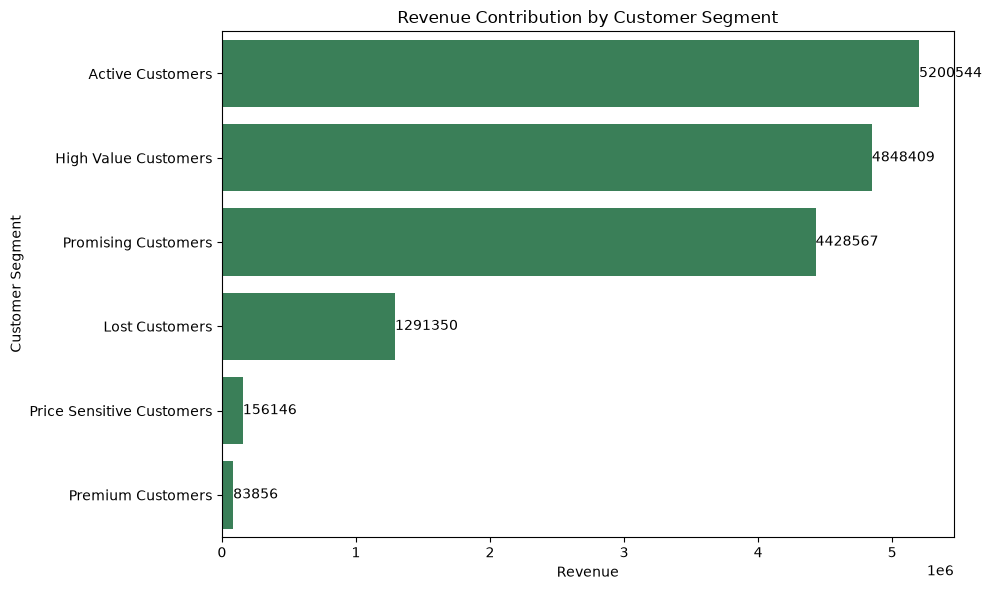

In [71]:
#Revenue Contribution
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=segment_summary.reset_index(),
    x="Total_Revenue",
    y="customer_segment",
    color="seagreen"
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Revenue")
plt.ylabel("Customer Segment")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

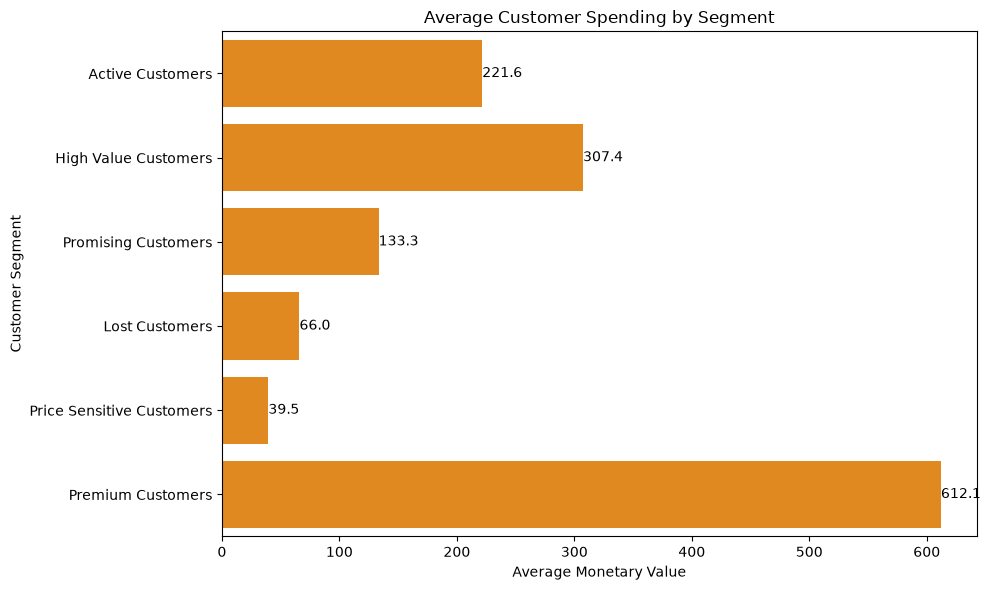

In [72]:
#Average Monetary Value
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=segment_summary.reset_index(),
    x="Avg_Monetary",
    y="customer_segment",
    color="darkorange"
)

plt.title("Average Customer Spending by Segment")
plt.xlabel("Average Monetary Value")
plt.ylabel("Customer Segment")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

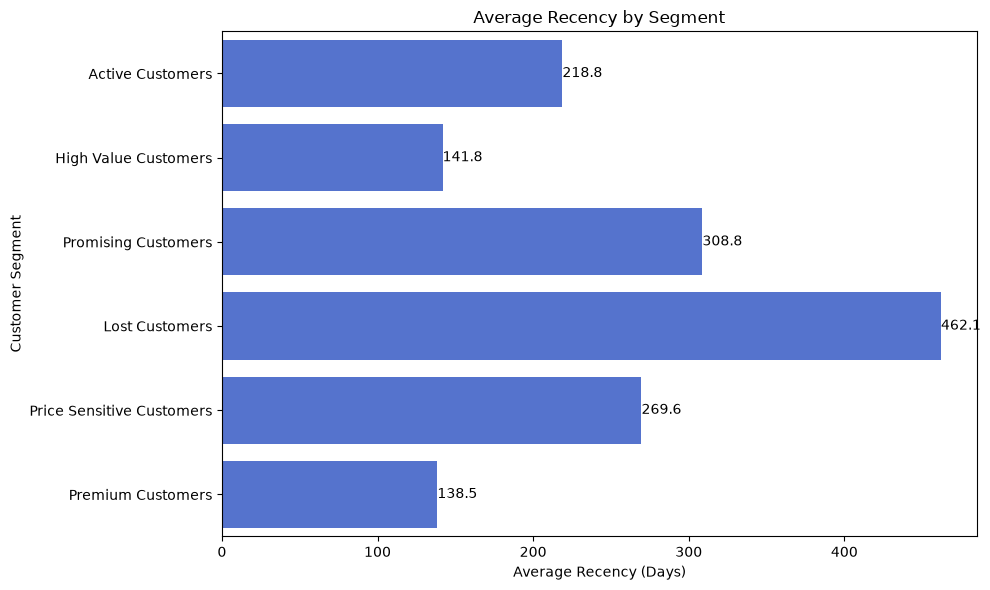

In [73]:
#Average Recency
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=segment_summary.reset_index(),
    x="Avg_Recency",
    y="customer_segment",
    color="royalblue"
)

plt.title("Average Recency by Segment")
plt.xlabel("Average Recency (Days)")
plt.ylabel("Customer Segment")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

#### Key Findings

- **Active Customers** contribute the highest revenue (**32.49%**) and represent **24.42%** of the customer base.
- **High Value Customers** contribute **30.29%** of total revenue with the second-highest average spending (**307.37**).
- **Promising Customers** form the largest customer segment (**34.56%**) and contribute **27.66%** of total revenue.
- **Lost Customers** account for **20.35%** of customers but generate only **8.07%** of revenue.
- **Premium Customers** have the highest average purchase value (**612.08**) and purchase frequency (**3.49**), but their overall revenue contribution is limited because they represent only **0.14%** of customers.

### Business Insights

- **Active Customers** are currently the most valuable segment because they combine a large customer base with the highest revenue contribution.
- **High Value Customers** spend significantly more than other segments and should be prioritized for loyalty and retention programs.
- **Promising Customers** represent the biggest opportunity for future growth. Increasing their purchase frequency could significantly improve overall revenue.
- **Lost Customers** have low engagement and contribute relatively little revenue, making them suitable for selective reactivation campaigns.
- Although **Premium Customers** contribute a small share of total revenue due to their limited size, they generate the highest revenue per customer and should receive personalized engagement to maximize long-term value.

In [80]:
#calculate percentage
segment_summary["Customer_%"] = (
    segment_summary["Customers"] /
    segment_summary["Customers"].sum()
) * 100

segment_summary["Revenue_%"] = (
    segment_summary["Total_Revenue"] /
    segment_summary["Total_Revenue"].sum()
) * 100

In [78]:
segment_summary.round(2)

,Customers,Customer_%,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_%,Avg_RFM_Score
customer_segment,,,,,,,,
Active Customers,23467,24.42,218.81,1.07,221.61,5200544.23,32.49,8.37
High Value Customers,15774,16.41,141.79,1.06,307.37,4848409.30,30.29,10.05
Promising Customers,33210,34.56,308.75,1.01,133.35,4428567.47,27.66,6.56
Lost Customers,19559,20.35,462.07,1.00,66.02,1291350.03,8.07,4.20
Price Sensitive Customers,3949,4.11,269.63,1.00,39.54,156145.57,0.98,5.00
Premium Customers,137,0.14,138.46,3.49,612.08,83855.52,0.52,12.68


In [79]:
print(f"Customer Percentage : {segment_summary['Customer_%'].sum():.2f}%")
print(f"Revenue Percentage : {segment_summary['Revenue_%'].sum():.2f}%")

Customer Percentage : 100.00%
Revenue Percentage : 100.00%


## 4.4 Business Recommendations

Based on the customer segmentation analysis, different customer groups require different business strategies. Instead of using a single marketing approach, businesses should focus on personalized engagement to improve retention, increase revenue, and maximize customer lifetime value.

In [82]:
#Marketing & Retention Strategy
marketing_strategy = pd.DataFrame({
    "Customer Segment": [
        "Premium Customers",
        "High Value Customers",
        "Active Customers",
        "Promising Customers",
        "Price Sensitive Customers",
        "Lost Customers"
    ],
    
    "Marketing Strategy": [
        "VIP rewards and exclusive offers",
        "Personalized product recommendations",
        "Cross-selling and upselling campaigns",
        "Email campaigns and promotional offers",
        "Discounts and limited-time deals",
        "Win-back campaigns and reminder emails"
    ],
    
    "Retention Strategy": [
        "Premium loyalty program",
        "Early access and membership benefits",
        "Regular engagement through personalized communication",
        "Convert to repeat buyers using targeted offers",
        "Price-based promotions",
        "Reactivation campaigns for selected customers"
    ]
})

marketing_strategy

,Customer Segment,Marketing Strategy,Retention Strategy
0,Premium Customers,VIP rewards and exclusive offers,Premium loyalty program
1,High Value Customers,Personalized product recommendations,Early access and membership benefits
2,Active Customers,Cross-selling and upselling campaigns,Regular engagement through personalized commun...
3,Promising Customers,Email campaigns and promotional offers,Convert to repeat buyers using targeted offers
4,Price Sensitive Customers,Discounts and limited-time deals,Price-based promotions
5,Lost Customers,Win-back campaigns and reminder emails,Reactivation campaigns for selected customers


## Conclusion

Customer segmentation provides a clear understanding of different customer groups and their contribution to the business.

The customized RFM approach used in this project reflects the characteristics of the Olist dataset more accurately than traditional segmentation methods. The insights generated from this analysis can support data-driven marketing, customer retention, and business growth initiatives.

The next phase of the project focuses on predicting customer churn using machine learning to identify customers who are likely to stop purchasing and enable proactive retention strategies.

In [86]:
rfm.to_csv(
    r"D:\customer pulse AI project\1 data\02_processed data\rfm_segmented_customers.csv",
    index=False
)

print(" File saved successfully!")

 File saved successfully!


In [87]:
import os

os.listdir(r"D:\customer pulse AI project\1 data\02_processed data")

['customers_clean.csv',
 'customer_360.csv',
 'orders_clean.csv',
 'order_items_clean.csv',
 'payments_clean.csv',
 'products_clean.csv',
 'reviews_clean.csv',
 'rfm_segmented_customers.csv',
 'sellers_clean.csv']